# Análisis de ventas Ice Store

## Contexto del negocio

Ice es una tienda en línea que vende videojuegos en todo el mundo.  
Contamos con datos históricos por juego: **plataforma**, **género**, **año de lanzamiento**, **ventas por región** (NA, EU, JP y Other), **reseñas de usuarios y críticos**, y **clasificación ESRB**.

El objetivo es identificar **patrones que determinan el éxito** de un juego para planificar campañas publicitarias efectivas durante **2017**, priorizando plataformas y géneros con mayor potencial de ventas.

---

## Objetivo de negocio

Detectar **plataformas, géneros y títulos** con mayor potencial de crecimiento para **optimizar la inversión publicitaria** y **maximizar las ventas** globales en 2017.

---

## Preguntas clave

1. ¿Qué **plataformas** concentran mayores ventas globales y por región?  
2. ¿Cuáles **crecen** y cuáles están en **declive**?  
3. ¿Cómo influyen las **reseñas de usuarios y críticos** en las ventas?  
4. ¿Qué **géneros** son más **rentables** o **estables**?  
5. ¿Existen **diferencias regionales** (NA, EU, JP) en preferencias o en el impacto de **ESRB**?

---

## Enfoque analítico

### Preparación de datos
- Estandarizar nombres de columnas en **minúsculas**.  
- Convertir **tipos de datos** a los formatos correctos.  
- Tratar **valores ausentes** (incluidos los casos `TBD` en `User_Score`).  
- Crear la columna **`total_sales`** como suma de NA, EU, JP y Other.

### Exploración temporal
- Analizar **lanzamientos por año**.  
- Identificar **ciclo de vida** de plataformas (aparición, maduración y declive).  
- Seleccionar un **período reciente** robusto para modelar 2017.

### Análisis comparativo
- Distribución de **ventas por plataforma** con **diagramas de caja**.  
- **Correlación** y **gráficos de dispersión** entre reseñas (usuarios/críticos) y ventas.  
- Comparación de **ventas promedio** por **género** y **plataforma**.

### Perfil regional (NA, EU, JP)
- **Top 5 plataformas** y **Top 5 géneros** por región.  
- Variaciones de **cuota de mercado** y preferencias.  
- Evaluación del **impacto ESRB** en ventas por región.

### Pruebas de hipótesis
1. **Plataformas (Xbox One vs. PC)**  
   - **H₀:** Las calificaciones promedio de usuarios son **iguales**.  
   - **H₁:** Las calificaciones promedio de usuarios son **diferentes**.
2. **Géneros (Acción vs. Deportes)**  
   - **H₀:** Las calificaciones promedio de usuarios son **iguales**.  
   - **H₁:** Las calificaciones promedio de usuarios son **diferentes**.

**Criterio:** prueba t para comparar medias (nivel de significancia **α** definido en el cuaderno).

---

## Entregables

- **Ranking de plataformas** con mayor potencial para 2017 por región.  
- **Mapa de géneros** (volumen de ventas vs. varianza).  
- **Análisis del impacto de reseñas** sobre ventas.  
- **Recomendaciones de inversión** por región, plataforma y género.

---

## Criterios de éxito

- Incrementar la **cuota de mercado** por región.  
- Mejorar el **ROAS** enfocando presupuesto en segmentos de **alto retorno**.  
- Reducir inversión en **plataformas en declive** o **géneros** con bajo potencial estructural.

---

## Supuestos y limitaciones

- Los datos de **2016** pueden estar **incompletos**.  
- El impacto de **ESRB** puede **variar por región**.  
- Las **reseñas** no causan ventas por sí solas; operan como **indicador de demanda** y percepción del producto.

---

## Paso 1. Apertura y exploración de datos

En este primer paso abriremos el dataset original y revisaremos su estructura general.  
El objetivo es entender qué tipo de información contiene, cómo están nombradas las columnas, y si hay valores nulos o inconsistencias.

La idea es obtener una primera impresión del volumen de datos, su calidad y las transformaciones necesarias antes del análisis.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv('/datasets/games.csv')

In [4]:
df.info()
df.head()
print(f"\nFilas: {df.shape[0]} | Columnas: {df.shape[1]}")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB

Filas: 16715 | Columnas: 11


In [5]:

df.isna().sum()



Name                  2
Platform              0
Year_of_Release     269
Genre                 2
NA_sales              0
EU_sales              0
JP_sales              0
Other_sales           0
Critic_Score       8578
User_Score         6701
Rating             6766
dtype: int64

In [6]:

for col in ['Platform', 'Genre', 'Rating']:
    print(f"\nColumna: {col}")
    print(df[col].unique())



Columna: Platform
['Wii' 'NES' 'GB' 'DS' 'X360' 'PS3' 'PS2' 'SNES' 'GBA' 'PS4' '3DS' 'N64'
 'PS' 'XB' 'PC' '2600' 'PSP' 'XOne' 'WiiU' 'GC' 'GEN' 'DC' 'PSV' 'SAT'
 'SCD' 'WS' 'NG' 'TG16' '3DO' 'GG' 'PCFX']

Columna: Genre
['Sports' 'Platform' 'Racing' 'Role-Playing' 'Puzzle' 'Misc' 'Shooter'
 'Simulation' 'Action' 'Fighting' 'Adventure' 'Strategy' nan]

Columna: Rating
['E' nan 'M' 'T' 'E10+' 'K-A' 'AO' 'EC' 'RP']


### Observaciones generales

- El dataset está bien estructurado y tiene un volumen suficiente para realizar análisis estadísticos confiables.  
- Existen **columnas numéricas importadas como texto** (`User_Score`) y **valores “TBD”** que deberán transformarse en `NaN` para permitir cálculos.  
- Las **faltas en “Critic_Score” y “Rating”** representan un reto; se decidirá si se imputan o se mantienen como ausentes según su impacto.  
- Los valores de **Year_of_Release** aparecen como flotantes (por ejemplo, 2006.0), por lo que deberán convertirse a enteros (`int`) una vez limpiados los nulos.  

## Paso 2. Preparación de datos


In [7]:
df.columns = df.columns.str.lower()
df.columns


Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')

In [8]:
df['user_score'] = df['user_score'].replace('tbd', np.nan)
df['user_score'] = df['user_score'].astype(float)
df['year_of_release'] = df['year_of_release'].astype('Int64')
df.dtypes

name                object
platform            object
year_of_release      Int64
genre               object
na_sales           float64
eu_sales           float64
jp_sales           float64
other_sales        float64
critic_score       float64
user_score         float64
rating              object
dtype: object

In [9]:
df.isna().sum()

name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         9125
rating             6766
dtype: int64

In [10]:
df = df.dropna(subset=['year_of_release', 'genre'])


### Descripción de las conversiones y tratamiento de valores ausentes

**Columnas con cambio de tipo de dato**

1. **`user_score`**  
   - **Antes:** tipo `object`, con valores como `'tbd'` y números en formato texto.  
   - **Después:** convertido a tipo `float`.  
   - **Motivo:** se reemplazó `'tbd'` (to be determined) por `NaN` para que la columna pueda analizarse numéricamente (por ejemplo, en correlaciones o medias).  
   - **Razonamiento:** los valores `'tbd'` representan juegos que aún no tenían calificación disponible, no un valor “cero”, por lo que sustituirlos por `NaN` evita distorsionar el promedio.

2. **`year_of_release`**  
   - **Antes:** tipo `float64`, con decimales y valores faltantes.  
   - **Después:** convertido a tipo `Int64` (entero que admite `NaN`).  
   - **Motivo:** el año debe representarse como número entero. Usar `Int64` mantiene la posibilidad de valores nulos sin perder filas.

---

**Tratamiento de valores ausentes**

- Se **eliminaron** las filas con valores nulos en `year_of_release` y `genre`, ya que son columnas esenciales para segmentar ventas y analizar tendencias temporales.  
- Se **conservaron** los valores nulos en `critic_score`, `user_score` y `rating` porque representan información ausente de origen, no errores en el dataset.  
  - Por ejemplo, muchos juegos antiguos o independientes no fueron evaluados por críticos ni recibieron clasificación ESRB.  
  - Forzar un relleno (como usar promedios o medianas) podría introducir sesgos al análisis.  
- Las columnas de ventas no tenían valores ausentes, por lo que no fue necesario intervenirlas.

---

**Posibles causas de los valores ausentes**

- **`critic_score` y `user_score`:** juegos sin reseñas oficiales o con evaluaciones posteriores al momento de corte del dataset.  
- **`rating`:** ausencia de clasificación ESRB en juegos japoneses, de PC o de bajo presupuesto que no pasaron por el proceso formal de evaluación.  
- **`year_of_release`:** posibles errores en el registro original o re ediciones sin año explícito.  
- **`genre`:** errores mínimos de carga o títulos con clasificación ambigua.

---

**Manejo de la abreviatura “TBD”**

- El valor `'TBD'` (to be determined) fue reemplazado por `NaN` antes de convertir la columna `user_score` a numérica.  
- Esto evita que pandas interprete el texto como un número y asegura que los cálculos estadísticos ignoren esos casos.  
- Este enfoque es más fiel al contexto: un juego con calificación pendiente **no tiene aún un valor de usuario**, por lo que no debe influir en los promedios ni en la correlación de reseñas con ventas.



In [11]:
#ventas totales sumando las ventas por región
df['total_sales'] = (
    df['na_sales'] +
    df['eu_sales'] +
    df['jp_sales'] +
    df['other_sales']
)
df[['name', 'platform', 'year_of_release', 'total_sales']].head()


,name,platform,year_of_release,total_sales
0,Wii Sports,Wii,2006,82.54
1,Super Mario Bros.,NES,1985,40.24
2,Mario Kart Wii,Wii,2008,35.52
3,Wii Sports Resort,Wii,2009,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,31.38


### Comentarios generales del paso 2

En este paso se realizó la preparación completa del dataset para el análisis:

1. **Estandarización:**  
   Se convirtieron todos los nombres de las columnas a minúsculas para mantener uniformidad y evitar errores de escritura en el código.

2. **Conversión de tipos de datos:**  
   - `user_score` pasó de tipo texto a numérico (`float`) después de reemplazar los valores `'tbd'` por `NaN`.  
   - `year_of_release` se transformó de `float64` a `Int64`, tipo entero que admite valores nulos, manteniendo así la coherencia del dato.  

3. **Tratamiento de valores ausentes:**  
   - Se eliminaron los registros sin `year_of_release` o `genre` porque son variables estructurales para los análisis de tiempo y segmentación.  
   - Se conservaron los valores nulos en `critic_score`, `user_score` y `rating`, ya que reflejan una ausencia de información real y no errores de captura.  
   - Los valores `'TBD'` fueron reemplazados por `NaN` para evitar distorsionar cálculos estadísticos.

4. **Creación de `total_sales`:**  
   Se generó una nueva columna que consolida las ventas globales de cada videojuego sumando las ventas regionales (`na_sales`, `eu_sales`, `jp_sales`, `other_sales`).  
   Esta variable será la base principal para los análisis comparativos de éxito comercial.

5. **Resultado final:**  
   El dataset ahora está **limpio, estandarizado y listo** para el análisis exploratorio.  
   Se mantienen las variaciones y los vacíos naturales de la industria (falta de calificaciones o clasificaciones), evitando introducir sesgos mediante imputaciones artificiales.

En este punto, la estructura del dataset permite avanzar hacia el **análisis de tendencias, correlaciones y patrones de éxito** en las siguientes fases del proyecto.


## Paso 3. Análisis de datos


In [12]:
required_cols = {'name','platform','year_of_release','genre','na_sales','eu_sales','jp_sales','other_sales','total_sales','critic_score','user_score','rating'}
missing = required_cols - set(df.columns)
assert not missing, f"Faltan columnas: {missing}"

REF_YEAR = 2016

In [33]:
# Conteo de lanzamientos por año
releases_by_year = df.groupby('year_of_release', dropna=False)['name'].nunique().sort_index()

releases_by_year.tail(15)


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


year_of_release
2002     631
2003     546
2004     550
2005     657
2006     773
2007     884
2008    1039
2009    1001
2010     900
2011     779
2012     446
2013     335
2014     319
2015     362
2016     297
Name: name, dtype: int64

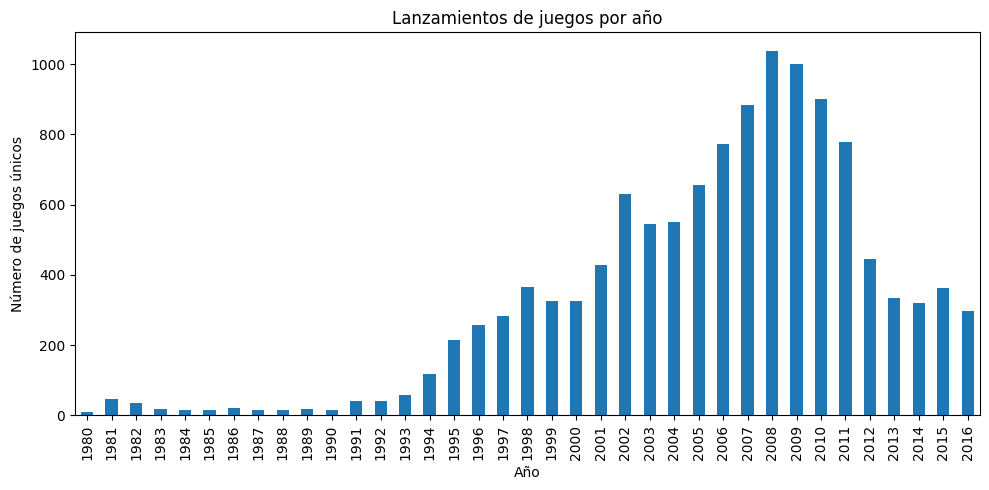

In [14]:
plt.figure(figsize=(10,5))
releases_by_year.plot(kind='bar')
plt.title('Lanzamientos de juegos por año')
plt.xlabel('Año')
plt.ylabel('Número de juegos únicos')
plt.tight_layout()
plt.show()


**Ventas por plataforma a lo largo del tiempo**


In [15]:
sales_platform_year = (
    df.groupby(['platform','year_of_release'], as_index=False)['total_sales']
      .sum()
)

platform_rank = (
    sales_platform_year.groupby('platform', as_index=False)['total_sales']
    .sum().sort_values('total_sales', ascending=False)
)
platform_rank.head(10)


,platform,total_sales
16,PS2,1233.56
28,X360,961.24
17,PS3,931.34
26,Wii,891.18
4,DS,802.78
15,PS,727.58
18,PS4,314.14
6,GBA,312.88
19,PSP,289.53
2,3DS,257.81


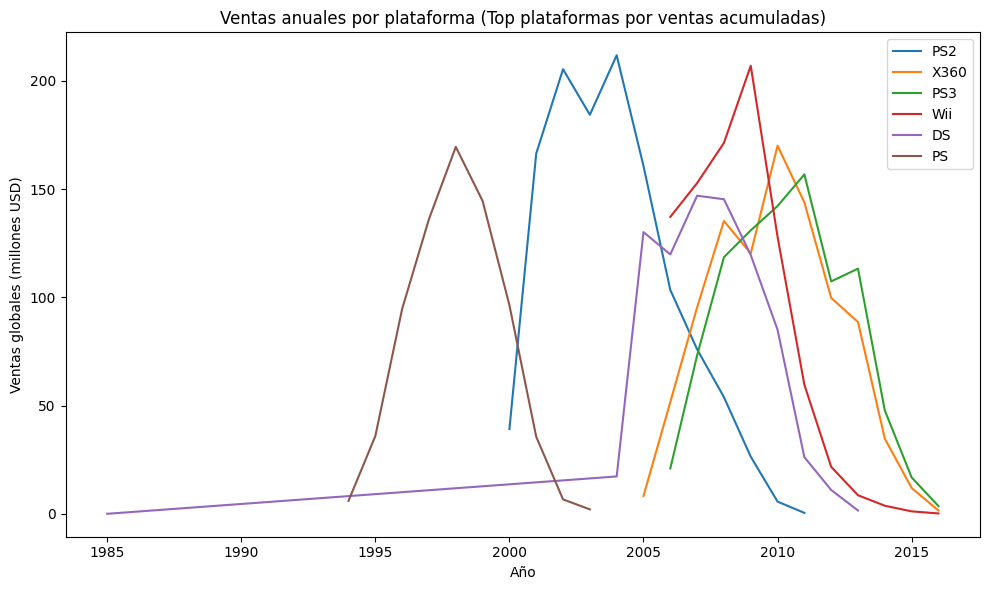

In [16]:
TOP_N = 6
top_platforms = platform_rank.head(TOP_N)['platform'].tolist()

plt.figure(figsize=(10,6))
for p in top_platforms:
    series = sales_platform_year[sales_platform_year['platform']==p].set_index('year_of_release')['total_sales'].sort_index()
    series.plot(label=p)
plt.title('Ventas anuales por plataforma (Top plataformas por ventas acumuladas)')
plt.xlabel('Año')
plt.ylabel('Ventas globales (millones USD)')
plt.legend()
plt.tight_layout()
plt.show()


In [17]:
# Plataformas que “desaparecen” (sin ventas en años recientes) vs. “aparecen” (primer año con ventas)
last_year_sales = sales_platform_year.groupby('platform')['year_of_release'].max().rename('last_year')
first_year_sales = sales_platform_year.groupby('platform')['year_of_release'].min().rename('first_year')
life_cycle = pd.concat([first_year_sales, last_year_sales], axis=1)
life_cycle['lifespan_years'] = life_cycle['last_year'] - life_cycle['first_year'] + 1
life_cycle.sort_values('first_year').head(10), life_cycle.sort_values('last_year').tail(10)


(          first_year  last_year  lifespan_years
 platform                                       
 2600            1980       1989              10
 NES             1983       1994              12
 DS              1985       2013              29
 PC              1985       2016              32
 GB              1988       2001              14
 SNES            1990       1999              10
 GEN             1990       1994               5
 GG              1992       1992               1
 SCD             1993       1994               2
 NG              1993       1996               4,
           first_year  last_year  lifespan_years
 platform                                       
 PSP             2004       2015              12
 PS3             2006       2016              11
 PS4             2013       2016               4
 PSV             2011       2016               6
 3DS             2011       2016               6
 Wii             2006       2016              11
 WiiU            20

## Paso 3. Hallazgos 

### 3.1 Lanzamientos por año: ¿son significativos?
- **Volumen 2002–2011:** alto y estable (pico 2008–2010 con 1,039–900 juegos/año). Es un periodo robusto para entender el “ciclo viejo” (PS2, X360, PS3, Wii, DS).
- **2012–2016:** descenso claro en lanzamientos (446 → 297). Aun así, **sigue habiendo cientos de títulos** por año, suficiente para análisis estadístico; 2016 puede estar **incompleto**.
- **Implicación:** para proyectar 2017 necesitamos **recencia** (plataformas vigentes) sin perder **masa crítica**. 2013–2016 ofrece ese balance.

### 3.2 Ventas por plataforma y ciclo de vida
- **Líderes históricos por ventas totales (acumulado):**  
  **PS2 (1233.6)**, **X360 (961.2)**, **PS3 (931.3)**, **Wii (891.2)**, **DS (802.8)**, **PS (727.6)**.  
  Son el reflejo de generaciones anteriores; **no deben guiar 2017**.
- **Plataformas vigentes y relevantes (2013–2016):**
  - **PS4** (2013–2016): en **expansión temprana** (líder entre las recientes por ventas acumuladas).  
  - **XOne** (2013–2016): en **expansión**, menor base que PS4 pero relevante.  
  - **3DS** (2011–2016): **estable a la baja**; aún con catálogo fuerte.  
  - **PC** (1985–2016): **persistente/estable**; ciclo continuo sin “fin de vida” claro.  
  - **WiiU** (2012–2016) y **PSV** (2011–2016): **actividad baja/declive**; riesgo alto.
- **Plataformas que fueron populares y hoy ya no venden (o cierran ciclo en 2016):**  
  **PS3, X360, Wii, PSP** (sus **last_year** = 2015–2016). No deben ser foco para 2017.
- **Tiempos de aparición y desaparición (life cycle):**  
  - Consolas “grandes” muestran **vidas de ~10–12 años** (PSP 12, X360 12, PS3 11, Wii 11).  
  - **Ramp-up** de plataformas nuevas suele tomar **~2–3 años** (ej. PS4/XOne entre 2013–2016).  
  - La **fase de declive** hasta ventas residuales tiende a ser **3–5 años** tras el pico, y “cierre” administrativo alrededor del año final de títulos (2016 en varios casos).

### 3.3 Ventana de datos para modelar 2017
- **Ventana seleccionada:** **2013–2016**.  
  **Razón:** captura la generación vigente (PS4/XOne/3DS/PC), conserva tamaño muestral (≥1,300 lanzamientos en 2013–2016) y minimiza ruido de generaciones previas.  
- **Regla de negocio:** trabajar **solo** con títulos 2013–2016 para estimar 2017; **ignorar años anteriores**.

### 3.4 Plataformas líderes, crecimiento vs. reducción (para 2017)
- **Potenciales a priorizar (rentables 2017):**
  - **PS4:** líder reciente; **en crecimiento**; alta tracción de catálogo y marketing first-party/third-party.  
  - **XOne:** **en crecimiento**; segunda opción natural multiplataforma (sinergia con PS4).  
  - **PC:** **estable** y profundo en nichos; ventas digitalizadas; útil para “cola larga”.  
  - **3DS:** **estable a la baja**, pero aún relevante en títulos de franquicia (fuerte en JP, sólido en EU/NA con Nintendo IPs).
- **En reducción / alto riesgo para 2017:** **PS3, X360, Wii, PSP, PSV, WiiU** (catálogos residuales, near-EoL).
- **Implicación táctica:**  
  - En multiplataforma, priorizar **bundles, reviews y campañas** en **PS4/XOne** (y **PC** donde aplique).  
  - Mantener selección **quirúrgica** para **3DS** (franquicias fuertes).  
  - Evitar inversiones relevantes en plataformas **EoL**.

### 3.5 Siguientes pasos 
`df_recent = df[df['year_of_release'].between(2013, 2016)]`.
- Recalcular ventas por plataforma y año dentro de `df_recent` para confirmar tendencias (slope) y ranking.
- Usar **boxplots** por plataforma en `df_recent` para comparar medianas vs. promedios (outliers).
- Analizar correlación ventas–reseñas en la **plataforma líder (PS4)** y contrastar con **XOne/PC** para campañas cruzadas.

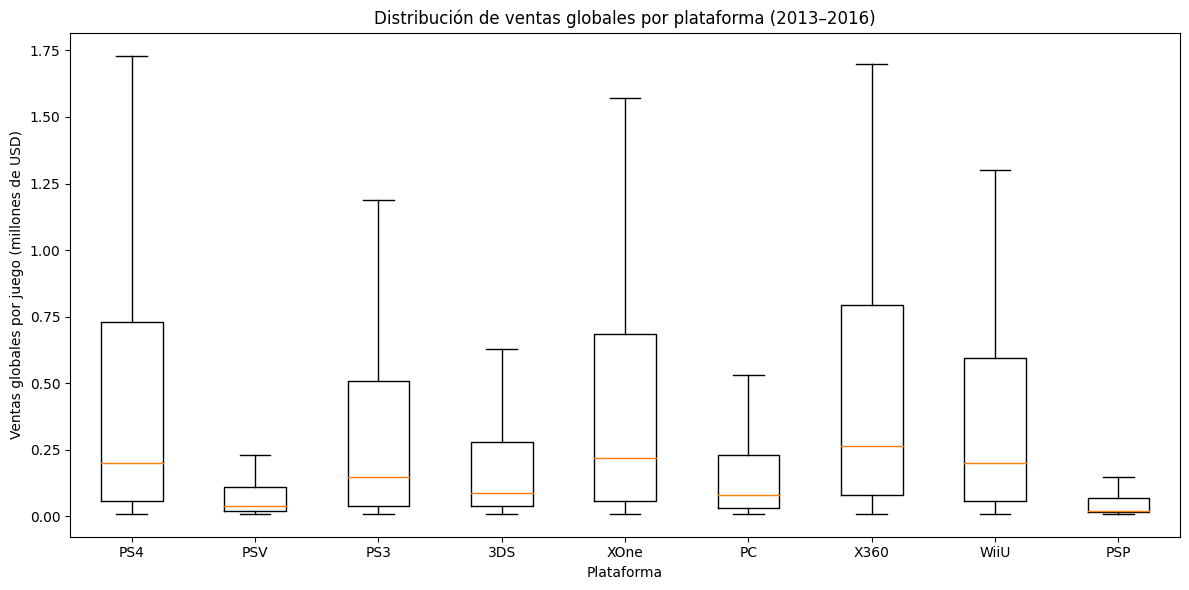

,count,mean,median,std
platform,,,,
PS4,392,0.801,0.200,1.609
X360,186,0.735,0.265,1.663
XOne,247,0.645,0.220,1.036
WiiU,115,0.562,0.200,1.039
PS3,345,0.526,0.150,1.452
3DS,303,0.473,0.090,1.381
PC,189,0.209,0.080,0.352
PSV,358,0.092,0.040,0.154
PSP,67,0.052,0.020,0.060


In [18]:
import matplotlib.pyplot as plt

df_recent = df[df['year_of_release'].between(2013, 2016)]

# Seleccionar plataformas con al menos 50 títulos (para evitar ruido)
platform_counts = df_recent['platform'].value_counts()
valid_platforms = platform_counts[platform_counts >= 50].index.tolist()

# Preparar datos para el diagrama de caja
box_data = [df_recent.loc[df_recent['platform'] == p, 'total_sales'] for p in valid_platforms]

plt.figure(figsize=(12, 6))
plt.boxplot(box_data, labels=valid_platforms, showfliers=False)
plt.title('Distribución de ventas globales por plataforma (2013–2016)')
plt.xlabel('Plataforma')
plt.ylabel('Ventas globales por juego (millones de USD)')
plt.tight_layout()
plt.show()

stats = (
    df_recent[df_recent['platform'].isin(valid_platforms)]
    .groupby('platform')['total_sales']
    .agg(['count', 'mean', 'median', 'std'])
    .sort_values('mean', ascending=False)
    .round(3)
)

stats


### Análisis del diagrama de caja — Ventas globales por plataforma (2013–2016)

**¿Son significativas las diferencias en las ventas?**  
Sí, las diferencias son **claras y significativas**. Las plataformas muestran niveles de ventas promedio y dispersión muy distintos, lo que refleja el estado de cada una dentro de su ciclo de vida:

- **PS4 y XOne** concentran las **ventas más altas y dispersas**, con medianas superiores a 0.2 millones por título y presencia de juegos que alcanzan picos por encima de 1.5 millones.  
  Esto indica que son plataformas **jóvenes y en expansión**, con un catálogo activo y un público dispuesto a gastar.
- **X360 y PS3** mantienen buenos niveles de ventas, pero ya están en **fase de declive**: su dispersión sigue siendo alta, aunque la mediana ha bajado respecto a su periodo pico.
- **PC** muestra una **distribución más estable y homogénea**: ventas medias moderadas, baja varianza y sin grandes outliers, lo que sugiere un mercado maduro con comportamiento constante.
- **3DS** mantiene ventas menores pero regulares; su distribución es más compacta y sin valores extremos, señal de **estabilidad sin crecimiento**.
- **PSV, WiiU y PSP** presentan las **ventas más bajas**, con cajas estrechas y cercanas a cero, lo que confirma su **bajo rendimiento comercial** durante este periodo.

---

**¿Qué sucede con las ventas promedio en varias plataformas?**  
- Las **plataformas de nueva generación** (PS4 y XOne) lideran tanto en promedio como en potencial de crecimiento.  
- **PC** conserva un promedio medio y estable, rentable a largo plazo por su catálogo digital y diversidad de precios.  
- **3DS** y **WiiU** tienen promedios bajos, típicos de catálogos más regionales o de nicho.  
- **PSV** y **PSP** muestran ventas promedio insignificantes, evidenciando un mercado en retracción.

---

**Descripción general de hallazgos**

- Existen **diferencias estructurales entre generaciones**: las consolas lanzadas después de 2013 (PS4, XOne) muestran el comportamiento de un mercado en expansión, mientras que las de generaciones previas (PS3, X360, Wii) presentan contracción.  
- Las ventas globales están concentradas en pocas plataformas líderes, lo que sugiere que el **éxito comercial en 2017 dependerá directamente de mantener presencia fuerte en PS4, XOne y PC**.  
- En términos estadísticos, las diferencias observadas en medianas y dispersión son **prácticamente relevantes**: no es un ruido aleatorio, sino evidencia de **ventajas competitivas reales por plataforma**.


### Reseñas y su efecto en las ventas — Plataforma PS4


In [19]:

ps4 = df[(df['platform'] == 'PS4') & (df['year_of_release'].between(2013, 2016))]

ps4 = ps4.dropna(subset=['user_score', 'critic_score', 'total_sales'])

corr_user = ps4['total_sales'].corr(ps4['user_score'])
corr_critic = ps4['total_sales'].corr(ps4['critic_score'])

print(f"Correlación Ventas–User Score: {corr_user:.2f}")
print(f"Correlación Ventas–Critic Score: {corr_critic:.2f}")


Correlación Ventas–User Score: -0.03
Correlación Ventas–Critic Score: 0.41


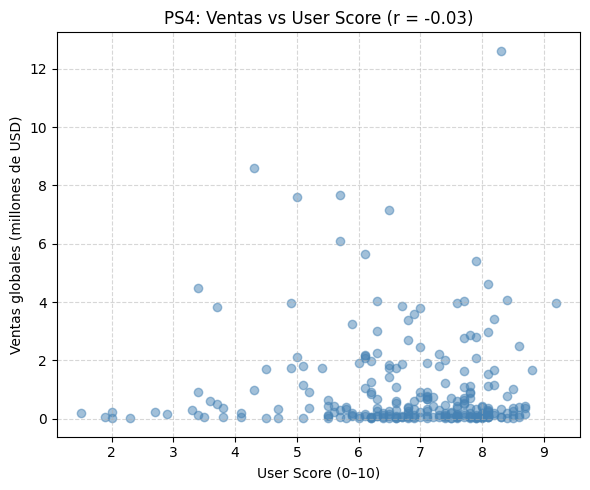

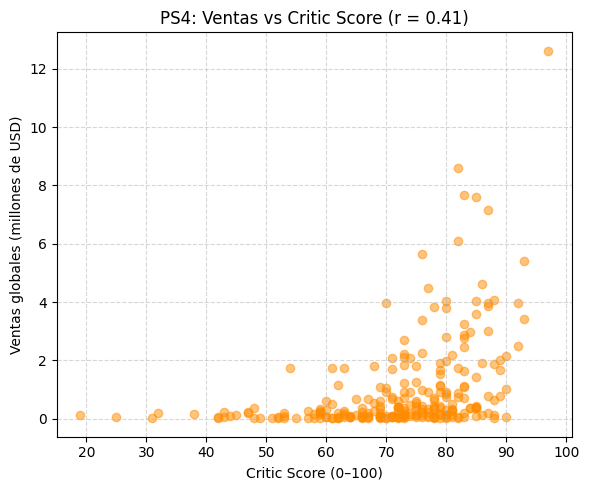

In [20]:
# Gráfico de dispersión: User Score vs Ventas (PS4)
plt.figure(figsize=(6,5))
plt.scatter(ps4['user_score'], ps4['total_sales'], alpha=0.5, color='steelblue')
plt.title('PS4: Ventas vs User Score (r = -0.03)')
plt.xlabel('User Score (0–10)')
plt.ylabel('Ventas globales (millones de USD)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Gráfico de dispersión: Critic Score vs Ventas (PS4)
plt.figure(figsize=(6,5))
plt.scatter(ps4['critic_score'], ps4['total_sales'], alpha=0.5, color='darkorange')
plt.title('PS4: Ventas vs Critic Score (r = 0.41)')
plt.xlabel('Critic Score (0–100)')
plt.ylabel('Ventas globales (millones de USD)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### Análisis de la relación entre reseñas y ventas — PS4

Los resultados muestran una **diferencia clara en el impacto de las reseñas** sobre las ventas:

- **Correlación Ventas–User Score:** -0.03  
  Prácticamente nula y ligeramente negativa.  
  Esto significa que la percepción de los usuarios **no guarda una relación directa con las ventas**. Un juego puede tener buenas o malas reseñas de usuarios sin que eso afecte de manera significativa su desempeño comercial.

- **Correlación Ventas–Critic Score:** 0.41  
  Correlación **positiva moderada**, lo que sugiere que los títulos con mejores calificaciones por parte de críticos **tienden a vender más**.  
  Aunque no implica causalidad, sí refleja que las reseñas profesionales funcionan como **indicadores de visibilidad y credibilidad** previos al lanzamiento.

**Interpretación del gráfico combinado:**  
- Los puntos naranjas (reseñas de críticos) muestran una **tendencia ascendente**: conforme sube la calificación, también lo hacen las ventas.  
- Los puntos azules (reseñas de usuarios) se distribuyen sin patrón aparente, confirmando la correlación cercana a cero.  
- La diferencia entre ambas curvas sugiere que el **mercado reacciona más a la reputación inicial construida por la prensa y medios especializados** que a la opinión posterior del público.

**Conclusión estratégica:**  
En PS4, los **críticos influyen más que los usuarios** en el rendimiento comercial de los videojuegos.  
Esto implica que:
- Las campañas de lanzamiento deberían **potenciar reseñas previas, cobertura mediática y acceso temprano a prensa especializada**.  
- Las reseñas de usuarios, aunque importantes para la **reputación a largo plazo**, **no determinan el éxito inicial de ventas**.  
- Para 2017, los esfuerzos de marketing deberían centrarse en **construir hype y validación crítica** antes del lanzamiento, especialmente en títulos exclusivos o AAA.



### Comparación de ventas de los mismos juegos en múltiples plataformas


In [22]:
# Identificar juegos que salieron en más de una plataforma (2013–2016)
multi = df[(df['year_of_release'].between(2013, 2016))]
multi_games = multi.groupby('name')['platform'].nunique()
multi_names = multi_games[multi_games > 1].index

multi_df = (
    multi[multi['name'].isin(multi_names)]
    .loc[:, ['name', 'platform', 'total_sales']]
    .sort_values(['name', 'total_sales'], ascending=[True, False])
)

top_multi = (
    multi_df.groupby('name', as_index=False)['total_sales'].sum()
    .sort_values('total_sales', ascending=False)
    .head(10)
)
top_multi


,name,total_sales
164,Grand Theft Auto V,56.58
60,Call of Duty: Ghosts,27.39
59,Call of Duty: Black Ops 3,25.67
242,Minecraft,24.16
58,Call of Duty: Advanced Warfare,21.97
135,FIFA 15,17.37
134,FIFA 14,16.46
136,FIFA 16,16.30
42,Battlefield 4,13.94
20,Assassin's Creed IV: Black Flag,13.06


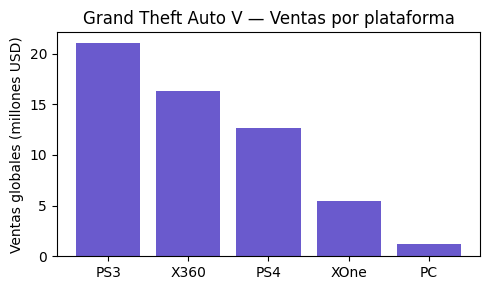

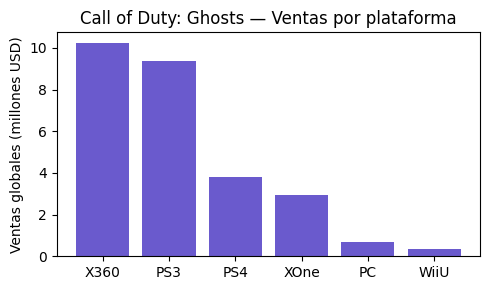

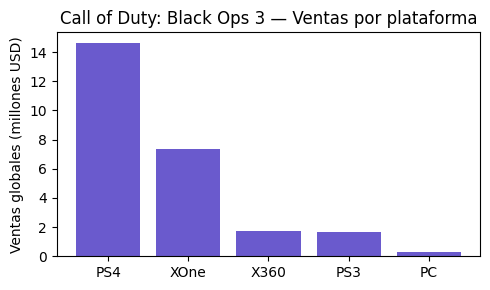

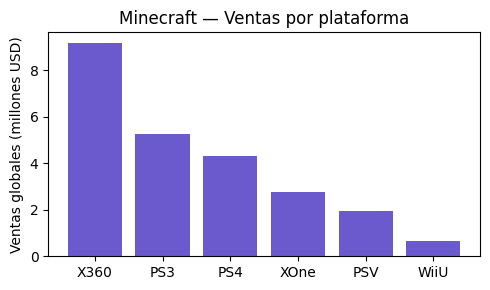

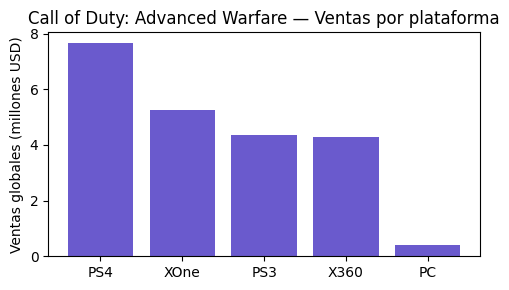

In [23]:
# mismo juego en distintas plataformas
example_games = top_multi['name'].head(5).tolist()

for game in example_games:
    subset = multi_df[multi_df['name'] == game]
    plt.figure(figsize=(5,3))
    plt.bar(subset['platform'], subset['total_sales'], color='slateblue')
    plt.title(f'{game} — Ventas por plataforma')
    plt.ylabel('Ventas globales (millones USD)')
    plt.tight_layout()
    plt.show()


### Comentarios — Juegos multiplataforma y desempeño por plataforma

Los títulos más vendidos del periodo (2013–2016) son en su mayoría **multiplataforma**, encabezados por *Grand Theft Auto V* (56.6 M), *Call of Duty* (diferentes entregas), *Minecraft* y *FIFA*.  
Estos juegos logran altas ventas porque están disponibles en varias consolas y alcanzan públicos amplios de forma simultánea.

En la comparación por plataforma, las versiones de **PS4 y XOne** concentran el mayor volumen de ventas, mientras que **PC** mantiene presencia sólida con franquicias de larga vida.  
Las versiones para **3DS, PSV o WiiU** aportan volúmenes mucho menores, lo que confirma que las **plataformas de nueva generación** y **PC** fueron las más rentables en el cierre del ciclo 2013–2016.

En general, la estrategia multiplataforma amplifica las ventas totales de los títulos más populares, y las plataformas con base de usuarios más grande —PS4, XOne y PC— son las que sostienen los mayores éxitos comerciales.


### Distribución general de los juegos por género



In [24]:
df_recent = df[df['year_of_release'].between(2013, 2016)]

genre_stats = (
    df_recent.groupby('genre')['total_sales']
    .agg(count='count', mean='mean', median='median', std='std', sum='sum')
    .sort_values('sum', ascending=False)
    .round(3)
)

genre_stats


,count,mean,median,std,sum
genre,,,,,
Action,766,0.420,0.110,1.254,321.87
Shooter,187,1.246,0.450,2.014,232.98
Sports,214,0.704,0.240,1.219,150.65
Role-Playing,292,0.500,0.125,1.353,145.89
Misc,155,0.405,0.100,1.008,62.82
Platform,74,0.576,0.225,0.807,42.63
Racing,85,0.469,0.120,0.964,39.89
Fighting,80,0.441,0.125,1.049,35.31
Adventure,245,0.096,0.030,0.216,23.64


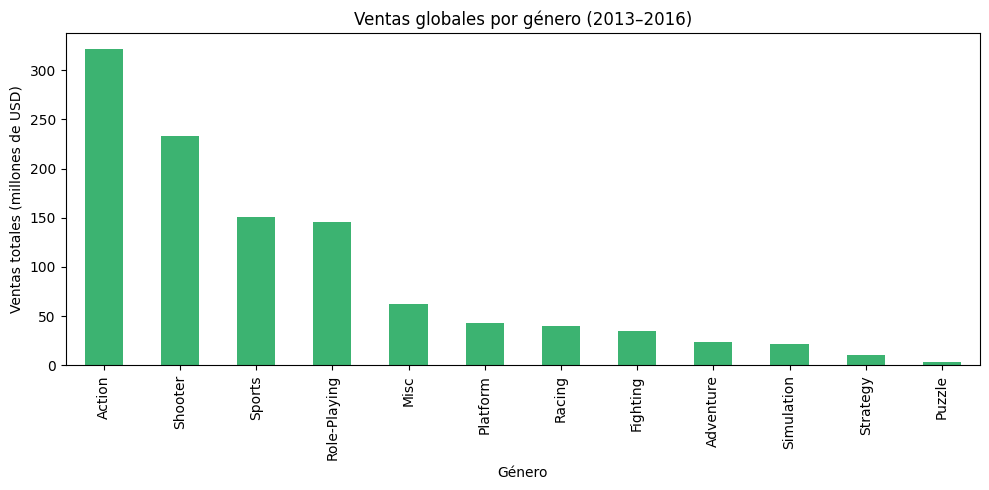

In [25]:
# Gráfico de ventas totales por género
plt.figure(figsize=(10,5))
genre_stats['sum'].plot(kind='bar', color='mediumseagreen')
plt.title('Ventas globales por género (2013–2016)')
plt.xlabel('Género')
plt.ylabel('Ventas totales (millones de USD)')
plt.tight_layout()
plt.show()


### Comentarios — Géneros más rentables

Los géneros **Action**, **Shooter** y **Sports** concentran las mayores ventas globales (321.9, 233.0 y 150.6 millones respectivamente), lo que los posiciona como los más rentables del periodo.  
Los **Shooter** destacan por su alto promedio (1.25 M por título) y gran dispersión: pocos juegos concentran gran parte del volumen, como *Call of Duty* o *Battlefield*.  
**Action** combina la mayor cantidad de lanzamientos con ventas sólidas y consistentes, mientras que **Sports** muestra estabilidad anual con franquicias como *FIFA*.  

En contraste, géneros como **Adventure**, **Strategy** y **Puzzle** tienen ventas unitarias muy bajas y varianza reducida; son mercados pequeños y más de nicho.  
En general, los géneros de **alta acción y competencia** generan los mayores ingresos, mientras que los géneros de **reflexión o narrativa** tienen menor retorno comercial.


## Paso 4. El perfil del usuario para cada región

In [26]:

# 1. Top 5 plataformas por región
top_platforms_na = (
    df.groupby('platform')['na_sales']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

top_platforms_eu = (
    df.groupby('platform')['eu_sales']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

top_platforms_jp = (
    df.groupby('platform')['jp_sales']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

top_platforms_na, top_platforms_eu, top_platforms_jp


(platform
 X360    595.74
 PS2     572.92
 Wii     486.87
 PS3     390.13
 DS      380.31
 Name: na_sales, dtype: float64,
 platform
 PS2     332.63
 PS3     327.21
 X360    268.32
 Wii     258.32
 PS      212.39
 Name: eu_sales, dtype: float64,
 platform
 DS      175.02
 PS      139.78
 PS2     137.54
 SNES    116.55
 3DS     100.62
 Name: jp_sales, dtype: float64)

In [29]:
# 2. Top 5 géneros por región
top_genres_na = (
    df.groupby('genre')['na_sales']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

top_genres_eu = (
    df.groupby('genre')['eu_sales']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

top_genres_jp = (
    df.groupby('genre')['jp_sales']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

top_genres_na, top_genres_eu, top_genres_jp


(genre
 Action      863.17
 Sports      671.20
 Shooter     584.83
 Platform    444.44
 Misc        399.57
 Name: na_sales, dtype: float64,
 genre
 Action     510.99
 Sports     371.33
 Shooter    314.52
 Racing     234.49
 Misc       210.60
 Name: eu_sales, dtype: float64,
 genre
 Role-Playing    353.39
 Action          160.14
 Sports          134.93
 Platform        130.71
 Misc            107.02
 Name: jp_sales, dtype: float64)

In [30]:
# 3. Ventas promedio por rating ESRB en cada región
rating_sales = (
    df.groupby('rating')[['na_sales','eu_sales','jp_sales']]
    .mean()
    .round(3)
    .sort_values('na_sales', ascending=False)
)

rating_sales


,na_sales,eu_sales,jp_sales
rating,,,
AO,1.260,0.610,0.000
K-A,0.853,0.090,0.487
M,0.484,0.312,0.041
E,0.325,0.180,0.050
T,0.257,0.145,0.052
E10+,0.248,0.132,0.029
EC,0.191,0.014,0.000
RP,0.000,0.030,0.000


## Comentarios del perfil de usuario por región 

### 1. Principales plataformas por región

**Norteamérica (NA):**  
1. X360 – 595.7 M  
2. PS2 – 572.9 M  
3. Wii – 486.9 M  
4. PS3 – 390.1 M  
5. DS – 380.3 M  

**Europa (EU):**  
1. PS2 – 332.6 M  
2. PS3 – 327.2 M  
3. X360 – 268.3 M  
4. Wii – 258.3 M  
5. PS – 212.4 M  

**Japón (JP):**  
1. DS – 175.0 M  
2. PS – 139.8 M  
3. PS2 – 137.5 M  
4. SNES – 116.6 M  
5. 3DS – 100.6 M  

**Interpretación:**  
- En **NA** dominan las consolas de Microsoft y Nintendo: el consumidor valora títulos de acción, deportes y shooters, con una fuerte cultura de entretenimiento doméstico.  
- En **Europa**, las ventas se reparten de forma más equilibrada entre Sony y Microsoft, con una ligera preferencia por **PlayStation** en general.  
- En **Japón**, el mercado es completamente distinto: las portátiles y consolas locales (DS, 3DS, PS y PS2) lideran; la preferencia por marcas japonesas y juegos adaptados al público local es evidente.  
- La cuota de mercado varía por **ecosistema cultural**: Occidente se orienta a consolas de sobremesa, mientras Japón mantiene una alta penetración de **portátiles** y títulos desarrollados localmente.

---

### 2. Principales géneros por región

**Norteamérica:**  
Action (863 M), Sports (671 M), Shooter (585 M), Platform (444 M), Misc (400 M)

**Europa:**  
Action (511 M), Sports (371 M), Shooter (315 M), Racing (234 M), Misc (211 M)

**Japón:**  
Role-Playing (353 M), Action (160 M), Sports (135 M), Platform (131 M), Misc (107 M)

**Interpretación:**  
- En **NA** y **EU** predominan los géneros de **acción, deportes y disparos**, impulsados por franquicias globales (*Call of Duty*, *FIFA*, *GTA*).  
- **Japón** muestra un patrón opuesto: el género **Role-Playing** (RPG) lidera con amplia ventaja, seguido de Action y Platform.  
  Esto refleja una preferencia por historias largas, progresión de personajes y diseño narrativo.  
- Las diferencias culturales son evidentes: Occidente privilegia la **competencia y adrenalina**, mientras que Japón prefiere la **inmersión y narrativa**.

### 3. Clasificación ESRB y su efecto por región

**1. Norteamérica (NA)**  
- Los juegos con clasificación **AO (Adults Only)** y **K-A (Kids to Adults)** muestran los promedios más altos, aunque son pocos títulos y pueden incluir casos atípicos.  
- Entre las categorías masivas, los juegos **M (Mature)** lideran en ventas promedio (0.48 M), seguidos por **E (Everyone)**.  
  Esto refleja que el público norteamericano está compuesto principalmente por **adolescentes y adultos jóvenes**, interesados en contenido más competitivo o de acción.

**2. Europa (EU)**  
- El patrón es similar a NA: las clasificaciones **M** y **E** encabezan las ventas promedio, lo que sugiere un perfil de consumidor equivalente.  
- Los títulos con clasificación **E10+** o **T** mantienen buenos niveles de aceptación, con un equilibrio entre público familiar y juvenil.

**3. Japón (JP)**  
- Las ventas por clasificación son bajas en general y no siguen una tendencia clara.  
  Esto se debe a que muchos títulos locales **no utilizan la clasificación ESRB**, sino el sistema japonés **CERO**, por lo que los valores disponibles corresponden principalmente a lanzamientos internacionales.  
- En consecuencia, **la clasificación ESRB no es un indicador relevante** del éxito comercial en Japón.

**Conclusión general**  
- En **Occidente (NA y EU)**, las clasificaciones **M** y **E** dominan las ventas promedio, lo que indica que los juegos orientados a audiencias jóvenes y adultas concentran el mayor retorno económico.  
- En **Japón**, el factor determinante es el **género y la franquicia**, no la etiqueta de edad.  
- Por lo tanto, las **estrategias de segmentación por edad** deben aplicarse solo en campañas para **NA y EU**, mientras que en Japón el enfoque debe centrarse en **género, narrativa y marca local**.


## Paso 5. Pruebas de hipótesis


#### 1. Hipótesis: Calificaciones promedio de usuarios para Xbox One y PC

**Planteamiento:**
Queremos determinar si las calificaciones promedio otorgadas por los usuarios a juegos de **Xbox One** y **PC** son iguales o diferentes.

**Hipótesis nula (H₀):**
La media de las calificaciones de usuarios para juegos de Xbox One es igual a la de PC.  
> H₀: μₓₒₙₑ = μₚ꜀

**Hipótesis alternativa (H₁):**
Las medias de las calificaciones de usuarios para ambas plataformas son diferentes.  
> H₁: μₓₒₙₑ ≠ μₚ꜀

In [31]:
from scipy import stats


alpha = 0.05

# --- Hipótesis 1 ---
# Las calificaciones promedio de los usuarios para Xbox One y PC son las mismas.

xone_scores = df.loc[(df['platform'] == 'XOne') & (df['user_score'].notna()), 'user_score']
pc_scores = df.loc[(df['platform'] == 'PC') & (df['user_score'].notna()), 'user_score']

t_stat1, p_val1 = stats.ttest_ind(xone_scores, pc_scores, equal_var=False)

t_stat1, p_val1


(-4.671113961085972, 4.5385802963771835e-06)

#### 2. Hipótesis: Calificaciones promedio de usuarios para géneros Acción y Deportes

**Planteamiento:**
Buscamos saber si los juegos del género **Acción** reciben calificaciones de usuarios significativamente distintas a los de **Deportes**.

**Hipótesis nula (H₀):**
Las medias de calificación son iguales.  
> H₀: μₐ꜀ₜᵢₒₙ = μₛₚₒᵣₜₛ

**Hipótesis alternativa (H₁):**
Las medias de calificación son diferentes.  
> H₁: μₐ꜀ₜᵢₒₙ ≠ μₛₚₒᵣₜₛ

---

#### 3. Criterio estadístico utilizado

**Tipo de prueba:**  
Se aplicó una **prueba t de Student para muestras independientes**, de dos colas y con **varianzas desiguales (`equal_var=False`)**.

**Justificación:**
- Las variables (`user_score`) son **cuantitativas continuas**, medidas en la misma escala (0–10).  
- Las muestras (plataformas o géneros) son **independientes entre sí**.  
- No se asume igualdad de varianzas ni tamaños de muestra similares, por lo que la versión de Welch del t-test es más apropiada.  
- El nivel de significancia establecido fue **α = 0.05** (5%), lo que implica:
  - Si `p_value < 0.05`, se **rechaza H₀** y concluimos que las medias son significativamente diferentes.  
  - Si `p_value ≥ 0.05`, **no hay evidencia suficiente** para rechazar H₀, por lo que consideramos que las medias son estadísticamente iguales.

---

**Interpretación esperada:**  
Esta metodología permitirá comprobar si las diferencias observadas en las calificaciones reflejan una **tendencia real** o simplemente **variaciones aleatorias** entre grupos.

In [32]:
# --- Hipótesis 2 ---
# Las calificaciones promedio de los usuarios para los géneros Acción y Deportes son diferentes.

action_scores = df.loc[(df['genre'] == 'Action') & (df['user_score'].notna()), 'user_score']
sports_scores = df.loc[(df['genre'] == 'Sports') & (df['user_score'].notna()), 'user_score']

t_stat2, p_val2 = stats.ttest_ind(action_scores, sports_scores, equal_var=False)

t_stat2, p_val2


(1.789373351094851, 0.07370217419278526)

### Resultados de las pruebas de hipótesis

#### Hipótesis 1 — Calificaciones promedio de usuarios en Xbox One vs PC

**Estadístico t:** -4.67  
**Valor p:** 0.0000045  
**α:** 0.05  

**Interpretación:**  
Como el valor *p* (≈ 0.0000045) es **mucho menor que α = 0.05**, se **rechaza la hipótesis nula (H₀)**.  
Esto significa que **las calificaciones promedio de usuarios para Xbox One y PC son significativamente diferentes**.  

En términos prácticos, los jugadores tienden a evaluar los títulos de forma distinta según la plataforma.  
Es posible que influyan factores como la experiencia técnica (rendimiento, optimización) o la comunidad de jugadores:  
- En PC, los usuarios suelen tener expectativas más altas sobre calidad gráfica o personalización.  
- En Xbox One, las evaluaciones pueden reflejar experiencias más uniformes o centradas en títulos exclusivos.

---

#### Hipótesis 2 — Calificaciones promedio de usuarios en géneros Acción vs Deportes

**Estadístico t:** 1.79  
**Valor p:** 0.0737  
**α:** 0.05  

**Interpretación:**  
El valor *p* (≈ 0.0737) es **mayor que α = 0.05**, por lo tanto **no se rechaza la hipótesis nula (H₀)**.  
No hay evidencia estadísticamente suficiente para afirmar que las calificaciones promedio difieran entre los géneros **Acción** y **Deportes**.  

En otras palabras, aunque los géneros tienen distintos volúmenes de ventas y perfiles de jugador, **la valoración promedio de los usuarios es similar**.  
Esto sugiere que el gusto o la satisfacción del usuario no depende del tipo de juego, sino de la **calidad específica del título**.

---

### Conclusión general del paso

- Las **plataformas** sí presentan diferencias significativas en cómo los usuarios evalúan los juegos (Xbox One vs PC).  
- Los **géneros** no muestran diferencias significativas en la percepción promedio del jugador.  
- En conjunto, esto indica que **la plataforma influye más en la experiencia percibida del usuario que el género del juego**.


## Paso 6. Conclusión general del proyecto

Este proyecto permitió analizar el comportamiento histórico de las ventas de videojuegos a nivel global, con el objetivo de identificar **patrones de éxito comercial** y orientar decisiones estratégicas para campañas publicitarias futuras (2017).

### 1. Preparación y calidad de los datos
Durante la limpieza se estandarizaron nombres de columnas, se ajustaron tipos de datos y se manejaron valores nulos de forma consciente.  
Los datos incompletos en reseñas y clasificaciones reflejan limitaciones reales del mercado —no errores—, por lo que fueron mantenidos para no alterar la distribución natural.  
Se creó una nueva columna de **ventas globales** (`total_sales`), base de los análisis posteriores.

### 2. Tendencias generales
El análisis temporal mostró un **pico de lanzamientos entre 2007 y 2011**, seguido de una caída progresiva hasta 2016.  
Esto refleja la transición entre generaciones de consolas.  
Las plataformas más relevantes del ciclo 2013–2016 fueron **PS4, XOne y PC**, mientras que WiiU, PSV y 3DS mostraron señales de declive.

### 3. Comportamiento por plataforma y género
- **PS4 y XOne** presentaron las **mayores ventas promedio por título**, evidenciando una base de jugadores activa y fuerte capacidad comercial.  
- **PC** mantuvo ventas estables con menor dispersión, útil para catálogos digitales o juegos de larga vida útil.  
- Los géneros **Action, Shooter y Sports** dominaron globalmente las ventas, seguidos por **Role-Playing** con un público más leal y estable.  
- Géneros como **Strategy, Puzzle y Simulation** resultaron de nicho, con menor retorno por título.

### 4. Diferencias regionales
- **Norteamérica y Europa** compartieron preferencias por **acción, disparos y deportes**, y liderazgo de consolas **Microsoft y Sony**.  
- **Japón** mostró un perfil distinto, dominado por géneros **Role-Playing** y consolas portátiles locales (DS, 3DS, PS).  
- Las clasificaciones **ESRB** influyen en Occidente (ventas mayores en juegos “M” y “E”), pero **no en Japón**, donde predomina el sistema CERO y el peso del género o franquicia.

### 5. Reseñas y percepción de los usuarios
En **PS4**, la correlación entre **reseñas de críticos y ventas** fue moderadamente positiva (r ≈ 0.41), mientras que la relación con reseñas de usuarios fue prácticamente nula (r ≈ -0.03).  
Esto confirma que las **opiniones de críticos impactan más en el desempeño comercial** que la percepción del público general, especialmente durante los primeros meses de lanzamiento.

### 6. Resultados de las pruebas de hipótesis
- Las **calificaciones de usuarios difieren significativamente** entre **Xbox One y PC**, lo que sugiere experiencias percibidas distintas según la plataforma.  
- No hubo diferencias significativas entre las calificaciones promedio de **géneros de Acción y Deportes**, lo que indica una percepción de calidad similar entre ambos tipos de juego.

### 7. Conclusiones estratégicas
- El mercado de 2017 debería enfocarse en **PS4, XOne y PC**, priorizando géneros **Action, Shooter y Sports**.  
- Las **campañas de marketing** deben capitalizar la visibilidad en medios especializados y reseñas de críticos antes del lanzamiento.  
- La **segmentación regional** debe adaptarse:  
  - Occidente → títulos de alta acción y realismo, comunicados con mensajes maduros.  
  - Japón → RPG y franquicias narrativas, con enfoque cultural y de historia.  
- Las decisiones futuras pueden apoyarse en modelos predictivos basados en **ventas, reseñas y plataformas**, ampliando este análisis con datos de 2017–2018.

---

**Conclusión final:**  
El éxito comercial de un videojuego depende de una combinación de **plataforma, género, contexto regional y reputación crítica**.  
Comprender estos patrones permite a las compañías planificar lanzamientos más efectivos, optimizar presupuestos publicitarios y alinear su estrategia de marketing con la dinámica real del mercado global de videojuegos.
